In [26]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torch.utils.data import random_split
import astropy.constants as c
import astropy.units as u

class VectorScalarDataset(Dataset):
    def __init__(self, X, y):
        """
        X: Tensor of shape (N, p) — inputs
        y: Tensor of shape (N,)   — scalar targets
        """
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

def cd_sed(nu, Beta, T, a=1):
    nu_c = 545 #GHz
    h_over_k = (c.h/c.k_B/(1*u.K)).to('GHz-1').value
    return a*(nu/nu_c)**(Beta+1)*(np.exp(h_over_k*nu_c/T) - 1)/(np.exp(h_over_k*nu/T) - 1)

def integral(bp_shift, Beta, T, bp_dat):
    return np.sum(bp_dat[1]*cd_sed(bp_dat[0]+bp_shift, Beta, T))


class NeuralNet(nn.Module):
    def __init__(self, hidden_size=8):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(3, hidden_size)            # first hidden layer (3 -> N)
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc3 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc4 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc5 = nn.Linear(hidden_size, 1)            # output layer (N -> 1 value)

    def forward(self, x):
        x = torch.relu(self.fc1(x))       # hidden layer 1 + ReLU activation, maybe try gelu
        x = torch.relu(self.fc2(x))       # hidden layer 2 + ReLU activation
        x = torch.relu(self.fc3(x))       # hidden layer 2 + ReLU activation
        x = torch.relu(self.fc4(x))       # hidden layer 2 + ReLU activation
        x = self.fc5(x).squeeze(-1)       # output layer (reduce to 1 value)
        return x
    
    def FLOPs_count(self):
        count = 2*self.fc1.in_features*self.fc1.out_features
        count += 2*self.fc2.in_features*self.fc2.out_features
        count += 2*self.fc3.in_features*self.fc3.out_features
        count += 2*self.fc4.in_features*self.fc4.out_features
        count += 2*self.fc5.in_features*self.fc5.out_features
        return count
    


In [2]:
# Device configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_data = torch.load("dataset_train.pt")
test_data = torch.load("dataset_val.pt")


y_mean = train_data["y"].mean()
y_std  = train_data["y"].std()

print(f"y mean: {y_mean:.2f}")   # expect ~1500
print(f"y std:  {y_std:.2f}")    # expect ~100-200

# Normalize
y_train_norm = (train_data["y"] - y_mean) / y_std
y_test_norm = (test_data["y"] - y_mean) / y_std

dataset = VectorScalarDataset(train_data["X"], y_train_norm)
test_dataset = VectorScalarDataset(test_data["X"], test_data["y"])

total = len(dataset)
val_size   = int(0.2 * total)
train_size = total - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

model = NeuralNet().to(device)

print("MODEL:")
print(model)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total}")
print(f"Total FLOPs: {model.FLOPs_count()}")

criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) #, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3, verbose=True
# )

y mean: 1516.18
y std:  151.02
MODEL:
NeuralNet(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
)
Trainable parameters: 257
Total FLOPs: 448


/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
#Train
num_epochs = 30
avg_t_loss_s = np.zeros(num_epochs)
avg_v_loss_s = np.zeros(num_epochs)
for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)      # move inputs to GPU
        y_batch = y_batch.to(device)      # move targets to GPU

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(y_batch)

    # --- Validation ---
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)  # move inputs to GPU
            y_batch = y_batch.to(device)  # move targets to GPU

            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            total_val_loss += loss.item() * len(y_batch)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    avg_val_loss   = total_val_loss   / len(val_loader.dataset)
    avg_t_loss_s[epoch] = avg_train_loss
    avg_v_loss_s[epoch] = avg_val_loss
    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")


Epoch 1: train=0.1875  val=0.0062
Epoch 2: train=0.0026  val=0.0015
Epoch 3: train=0.0013  val=0.0012
Epoch 4: train=0.0012  val=0.0012
Epoch 5: train=0.0012  val=0.0011
Epoch 6: train=0.0012  val=0.0011
Epoch 7: train=0.0011  val=0.0011
Epoch 8: train=0.0010  val=0.0009
Epoch 9: train=0.0010  val=0.0009
Epoch 10: train=0.0009  val=0.0009
Epoch 11: train=0.0009  val=0.0009
Epoch 12: train=0.0009  val=0.0009
Epoch 13: train=0.0008  val=0.0007
Epoch 14: train=0.0006  val=0.0005
Epoch 15: train=0.0004  val=0.0004
Epoch 16: train=0.0003  val=0.0003
Epoch 17: train=0.0002  val=0.0002
Epoch 18: train=0.0002  val=0.0002
Epoch 19: train=0.0002  val=0.0002
Epoch 20: train=0.0002  val=0.0002
Epoch 21: train=0.0002  val=0.0002
Epoch 22: train=0.0002  val=0.0002
Epoch 23: train=0.0002  val=0.0003
Epoch 24: train=0.0002  val=0.0002
Epoch 25: train=0.0002  val=0.0002
Epoch 26: train=0.0002  val=0.0002
Epoch 27: train=0.0002  val=0.0002
Epoch 28: train=0.0002  val=0.0002
Epoch 29: train=0.0002  val=0

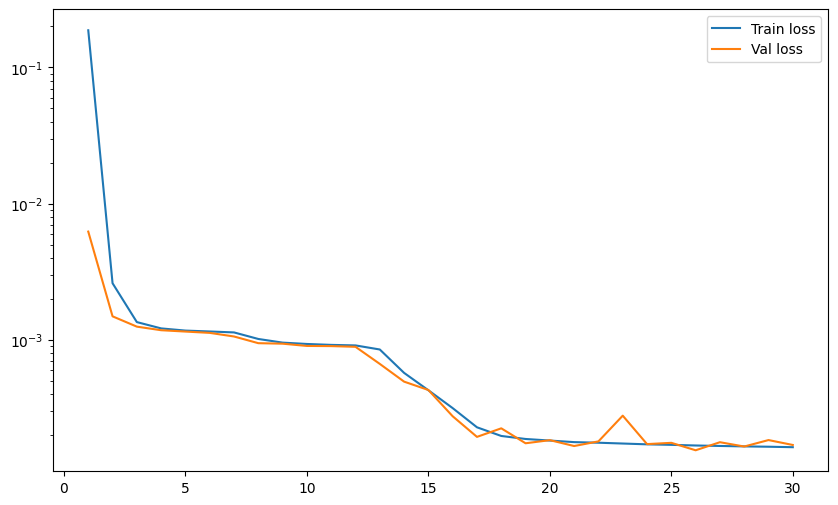

In [4]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(1, num_epochs+1), avg_t_loss_s, label="Train loss")
plt.plot(np.arange(1, num_epochs+1), avg_v_loss_s, label="Val loss")
plt.yscale('log')
plt.savefig("training.png")
plt.legend()
plt.close

if True:
    torch.save({
        'model_state_dict': model.state_dict(),
        'y_mean': y_mean,
        'y_std':  y_std,
        }, 'bandpass_NN_v1.pth')

In [5]:
#Evaluation on the Test Set

model = NeuralNet()    # instantiate architecture first
model_setup_dict = torch.load('bandpass_NN_v1.pth', map_location=device)
model.load_state_dict(model_setup_dict['model_state_dict'])
y_std, y_mean = model_setup_dict['y_std'], model_setup_dict['y_mean'] 
model.to(device)
model.eval()


NeuralNet(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
)

In [51]:
with torch.no_grad():
    # Single sample
    errs = []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)  # move inputs to GPU
        y_batch = y_batch.to(device)  # move targets to GPU

        pred_norm = model(X_batch[0])
        pred = pred_norm * y_std + y_mean           # denormalize output
        err = abs((pred - y_batch[0].item()))/y_batch[0].item()
        print(f"Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
        errs.append(err)
        loss  = criterion(pred, y_batch)
        total_val_loss += loss.item() * len(y_batch)

Preds = 1694.5366, True = 1695.1029, err = 0.0003340918798602892
Preds = 1430.1311, True = 1426.6996, err = 0.0024051989939363116
Preds = 1422.2558, True = 1418.1403, err = 0.0029020534429827394
Preds = 1521.2167, True = 1522.9858, err = 0.0011616112934616047
Preds = 1394.9551, True = 1388.5570, err = 0.00460771533143838
Preds = 1583.5067, True = 1585.1897, err = 0.0010616920748169941
Preds = 1656.6899, True = 1654.8971, err = 0.0010833321345115059
Preds = 1698.7857, True = 1695.3142, err = 0.0020477267285461246
Preds = 1705.8988, True = 1702.7600, err = 0.0018433818415155166
Preds = 1730.7158, True = 1728.6213, err = 0.0012116153900570117
Preds = 1346.4026, True = 1345.4294, err = 0.0007233179486120508
Preds = 1546.5313, True = 1549.5347, err = 0.001938251517044144
Preds = 1275.0106, True = 1275.7250, err = 0.0005599501372083667
Preds = 1261.9695, True = 1263.9546, err = 0.0015705021112168138
Preds = 1277.6923, True = 1278.1482, err = 0.00035670836834328633
Preds = 1360.9560, True = 1

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


Preds = 1514.8113, True = 1517.2310, err = 0.0015948028602448595
Preds = 1441.8606, True = 1439.6896, err = 0.0015079791997069936
Preds = 1842.7089, True = 1844.7401, err = 0.0011010743460395228
Preds = 1781.3031, True = 1778.9622, err = 0.001315888073901603
Preds = 1623.8988, True = 1625.5643, err = 0.0010245773380412391
Preds = 1742.5373, True = 1741.6476, err = 0.0005108586411347918
Preds = 1487.5643, True = 1489.9515, err = 0.0016022137684314135
Preds = 1555.9333, True = 1560.5275, err = 0.002943989352665883
Preds = 1666.6388, True = 1664.6699, err = 0.0011827161751368838
Preds = 1561.0746, True = 1565.8180, err = 0.003029340487648465
Preds = 1673.0809, True = 1670.6246, err = 0.0014702805979671643
Preds = 1383.1702, True = 1383.6681, err = 0.0003598680108034648
Preds = 1412.3502, True = 1413.1625, err = 0.0005748174959001753
Preds = 1555.0895, True = 1556.1472, err = 0.0006796892824025199
Preds = 1465.9506, True = 1464.0322, err = 0.0013103610456473432
Preds = 1576.9158, True = 15

In [25]:
model(torch.tensor([[0, 1.8, 10], [0, 1.8, 10], [0, 1.8, 10], [0, 1.8, 10]]))

tensor([-1.6675, -1.6675, -1.6675, -1.6675], grad_fn=<SqueezeBackward1>)

In [23]:
torch.tensor([[0, 1.8, 10], [0, 1.8, 10], [0, 1.8, 10], [0, 1.8, 10]])

tensor([[ 0.0000,  1.8000, 10.0000],
        [ 0.0000,  1.8000, 10.0000],
        [ 0.0000,  1.8000, 10.0000],
        [ 0.0000,  1.8000, 10.0000]])

In [54]:
samp_intervals = {
    "BP_shift":(-10., 10.),
    "Beta":(1.8, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0   # fix third feature at a specific value

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')

X_grid = torch.stack([
    grid_b.flatten(),
    grid_t.flatten(),
    torch.full((N_vals*N_vals,), bp_s_fixed)   # constant third feature
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
batch_size = 1024
all_preds  = []
all_true = []
with torch.no_grad():
    for i in range(0, len(X_grid), batch_size):
        batch = X_grid[i:i+batch_size].to(device)
        print(batch[0,0])
        preds = model(batch) * y_std + y_mean
        all_preds.append(preds.cpu())

all_preds = np.array(torch.cat(all_preds))   # shape: (N,)
print(all_preds.shape)

#true integrals
for t in np.linspace(samp_intervals["T"][0], samp_intervals["T"][1], num=N_vals):
    for beta in np.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], num=N_vals):
        all_true.append(integral(bp_s_fixed, beta, t, bp_dat))
all_true=np.array(all_true)

tensor(1.8000)
tensor(1.8303)
tensor(1.8606)
tensor(1.8909)
tensor(1.9212)
tensor(1.9545)
tensor(1.9848)
tensor(2.0152)
tensor(2.0455)
tensor(2.0788)
(10000,)


/tmp/ipykernel_37871/2735721619.py:37: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_preds = np.array(torch.cat(all_preds))   # shape: (N,)


In [56]:
all_preds


array([584.34827, 584.3034 , 584.25867, ..., 575.519  , 575.4967 ,
       575.4743 ], shape=(10000,), dtype=float32)